# Raw data

In [1]:
from util.data_fft import *
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft, fftfreq
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import RidgeClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

import itertools
from itertools import chain, combinations
from sklearn.preprocessing import normalize
import pickle
import copy
import pandas as pd
from IPython.display import display, HTML
from scipy.signal import find_peaks
from scipy.stats import skew, entropy, kurtosis
import seaborn as sns
import pyxai
from pyxai import Learning, Explainer, Tools
from util.explain_models import *
import tqdm
import shap
import time
from sklearn.tree import export_graphviz
import graphviz

/Users/morvan/Documents/Recherche/Publications/XAI_ITSC_2026/itsc-xai-generators/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load raw data

In [2]:
data_fft = pd.read_csv('data/itsc_generators_edf_v1.0.csv')
display(data_fft)

,3.3 Hz,6.7 Hz,10 Hz,13.3 Hz,16.7 Hz,20 Hz,23.3 Hz,26.7 Hz,30.0 Hz,33.3 Hz,36.7 Hz,40 Hz,43.3 Hz,46.7 Hz,y,Machine
0,0.003823,0.006244,0.009360,0.006350,0.011895,0.003084,0.004992,0.003583,0.002899,0.004486,0.002296,0.003973,0.002023,0.009182,0,E
1,0.003120,0.004690,0.006866,0.004514,0.008899,0.001253,0.003436,0.002102,0.002641,0.003109,0.000343,0.002801,0.005365,0.002798,0,E
2,0.003904,0.006731,0.009307,0.006487,0.010539,0.002833,0.005094,0.003233,0.002605,0.003909,0.002039,0.003685,0.001897,0.007596,0,E
3,0.002495,0.004428,0.006738,0.005906,0.009899,0.002494,0.005030,0.003931,0.000839,0.004511,0.003686,0.004014,0.001420,0.012222,0,E
4,0.002107,0.003078,0.003943,0.003887,0.008632,0.002485,0.001238,0.002171,0.000282,0.002441,0.000674,0.003722,0.003891,0.011018,0,E
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,0.009815,0.010288,0.004735,0.004409,0.018036,0.022986,0.019295,0.004795,0.005513,0.009084,0.012807,0.009289,0.001562,0.011203,1,A
86,0.003257,0.001131,0.001011,0.000957,0.005961,0.010337,0.008621,0.002342,0.005213,0.003704,0.004338,0.002292,0.001172,0.003184,1,A
87,0.005867,0.003401,0.001492,0.003290,0.012677,0.017022,0.014693,0.003215,0.006826,0.005421,0.009559,0.007115,0.001118,0.009298,1,A
88,0.002854,0.000671,0.001469,0.000268,0.005062,0.009380,0.008365,0.003199,0.002830,0.002925,0.001969,0.003003,0.003951,0.006794,1,A


## Feature selection

In [3]:
data_diff = data_fft.drop(data_fft.columns[-2:], axis=1)
display(data_diff)
print("Generating power sets")
data_diff_ps = column_power_set(data_diff, 5, 5)
n_sets = len(data_diff_ps)
print("number of feature sets", n_sets)

,3.3 Hz,6.7 Hz,10 Hz,13.3 Hz,16.7 Hz,20 Hz,23.3 Hz,26.7 Hz,30.0 Hz,33.3 Hz,36.7 Hz,40 Hz,43.3 Hz,46.7 Hz
0,0.003823,0.006244,0.009360,0.006350,0.011895,0.003084,0.004992,0.003583,0.002899,0.004486,0.002296,0.003973,0.002023,0.009182
1,0.003120,0.004690,0.006866,0.004514,0.008899,0.001253,0.003436,0.002102,0.002641,0.003109,0.000343,0.002801,0.005365,0.002798
2,0.003904,0.006731,0.009307,0.006487,0.010539,0.002833,0.005094,0.003233,0.002605,0.003909,0.002039,0.003685,0.001897,0.007596
3,0.002495,0.004428,0.006738,0.005906,0.009899,0.002494,0.005030,0.003931,0.000839,0.004511,0.003686,0.004014,0.001420,0.012222
4,0.002107,0.003078,0.003943,0.003887,0.008632,0.002485,0.001238,0.002171,0.000282,0.002441,0.000674,0.003722,0.003891,0.011018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,0.009815,0.010288,0.004735,0.004409,0.018036,0.022986,0.019295,0.004795,0.005513,0.009084,0.012807,0.009289,0.001562,0.011203
86,0.003257,0.001131,0.001011,0.000957,0.005961,0.010337,0.008621,0.002342,0.005213,0.003704,0.004338,0.002292,0.001172,0.003184
87,0.005867,0.003401,0.001492,0.003290,0.012677,0.017022,0.014693,0.003215,0.006826,0.005421,0.009559,0.007115,0.001118,0.009298
88,0.002854,0.000671,0.001469,0.000268,0.005062,0.009380,0.008365,0.003199,0.002830,0.002925,0.001969,0.003003,0.003951,0.006794


Generating power sets
number of feature sets 2002


In [26]:
best_features_min = {'features':None, 'min_accuray':0, 'mean_accuracy':0}
best_features_mean = {'features':None, 'min_accuray':0, 'mean_accuracy':0}
for d in data_diff_ps:
    data = pd.concat([d, data_fft['y'], data_fft['Machine']], axis=1)

    min_a, mean_a = cross_validation(data, n_runs=10, data_representation='raw');
    if min_a >= best_features_min['min_accuray']:
        best_features_min['features'] = d.columns.tolist()
        best_features_min['min_accuray'] = min_a
        best_features_min['mean_accuracy'] = mean_a
print(best_features_min)        

{'features': ['6.7 Hz', '16.7 Hz', '23.3 Hz', '30.0 Hz', '46.7 Hz'], 'min_accuray': 0.5333333333333333, 'mean_accuracy': 0.6622222222222222}


## Training a DT with selected features

In [8]:
data_diff = data_diff[['6.7 Hz', '16.7 Hz', '23.3 Hz', '30.0 Hz', '46.7 Hz']]
data_diff = pd.concat([data_diff, data_fft['y'], data_fft['Machine']], axis=1)
m = cross_validation(data_diff, n_runs=1, data_representation='raw', verbose=True);

Split 1:
  Train Machines: ['D', 'B', 'C', 'F', 'A']
  Test Machine: E
  Accuracy: 0.6000
  F1-Score: 0.7500
Split 2:
  Train Machines: ['E', 'B', 'C', 'F', 'A']
  Test Machine: D
  Accuracy: 0.8667
  F1-Score: 0.9286
Split 3:
  Train Machines: ['E', 'D', 'C', 'F', 'A']
  Test Machine: B
  Accuracy: 0.5333
  F1-Score: 0.6957
Split 4:
  Train Machines: ['E', 'D', 'B', 'F', 'A']
  Test Machine: C
  Accuracy: 0.7333
  F1-Score: 0.8462
Split 5:
  Train Machines: ['E', 'D', 'B', 'C', 'A']
  Test Machine: F
  Accuracy: 0.5333
  F1-Score: 0.6957
Split 6:
  Train Machines: ['E', 'D', 'B', 'C', 'F']
  Test Machine: A
  Accuracy: 0.7333
  F1-Score: 0.8462
min:  0.5333333333333333
mean:  0.6666666666666666


## Computing logical explanations

In [12]:
data_x = data_diff.drop(data_diff.columns[-1:], axis=1)
learner = Learning.Scikitlearn(data_x, learner_type=Learning.CLASSIFICATION)

model = learner.evaluate(method=Learning.HOLD_OUT, output=Learning.DT, test_size=0.2, class_weight={0: 1, 1: 2},  max_features=8, max_depth=3)
instances = learner.get_instances(model, correct=True, predictions=[1])

t1 = time.time()
display_reasons_for_model(learner, model, instances, {1:"fault"})
t2 = time.time()
print("Computation time: ", str(t2-t1))

data:
      6.7 Hz   16.7 Hz   23.3 Hz   30.0 Hz   46.7 Hz  y
0   0.006244  0.011895  0.004992  0.002899  0.009182  0
1   0.004690  0.008899  0.003436  0.002641  0.002798  0
2   0.006731  0.010539  0.005094  0.002605  0.007596  0
3   0.004428  0.009899  0.005030  0.000839  0.012222  0
4   0.003078  0.008632  0.001238  0.000282  0.011018  0
..       ...       ...       ...       ...       ... ..
85  0.010288  0.018036  0.019295  0.005513  0.011203  1
86  0.001131  0.005961  0.008621  0.005213  0.003184  1
87  0.003401  0.012677  0.014693  0.006826  0.009298  1
88  0.000671  0.005062  0.008365  0.002830  0.006794  1
89  0.002005  0.009414  0.012669  0.006346  0.001662  1

[90 rows x 6 columns]
--------------   Information   ---------------
Dataset name: pandas.core.frame.DataFrame
nFeatures (nAttributes, with the labels): 6
nInstances (nObservations): 90
Labels Encoding (with indexes): OrderedDict({0: '0', 1: '1'})
nLabels: 2
---------------   Evaluation   ---------------
evaluation meth

• 30.0 Hz in ]0.003773072618059814, 0.007097270106896758]


• 30.0 Hz in ]0.003773072618059814, 0.007097270106896758]
Computation time:  0.008916854858398438


## Export DT

In [13]:
feature_names = ['6.7 Hz', '16.7 Hz', '23.3 Hz', '30.0 Hz', '46.7 Hz']
class_names = ["OK", "fault"]
dot_data = export_graphviz(
    model.learner_information.raw_model,
    out_file=None,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    special_characters=True
)
graph = graphviz.Source(dot_data)
graph.format = "pdf"
graph.render("dt_f1")

'dt_f1.pdf'

## SHAP Explanations

Shape of shap_values: (90, 5, 2)


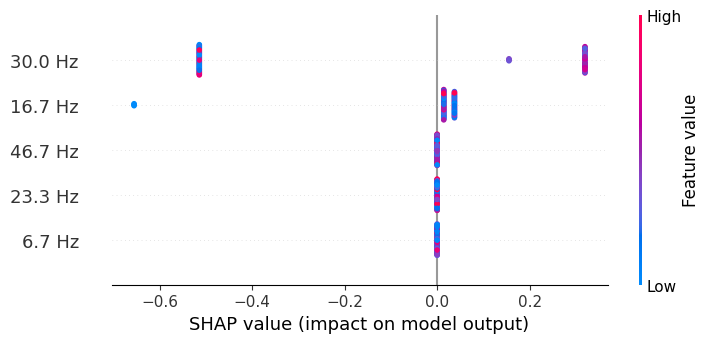

In [14]:
X = data_diff.drop(data_diff.columns[-2:], axis=1).to_numpy()
y = data_diff['y'].to_numpy()
model = DecisionTreeClassifier(class_weight='balanced', max_features=8, max_depth=3)
model.fit(X, y)

feature_names = data_diff.drop(data_diff.columns[-2:], axis=1).columns.tolist()
explainer = shap.TreeExplainer(model, feature_names = feature_names)
shap_values = explainer(X)

# Print the shape of shap_values to understand its structure
print("Shape of shap_values:", shap_values.shape)

# Check if the model has multiple outputs
if len(shap_values.shape) == 3:
    # For multi-output models, select the first output
    shap_values_single_output = shap_values[:, :, 1]
else:
    shap_values_single_output = shap_values

shap.plots.beeswarm(shap_values_single_output)

## Decision Rule 4


In [17]:
data_diff = data_fft
nb_fault = data_diff['y'].value_counts()[1]
nb_healthy = data_diff['y'].value_counts()[0]
threshold = 0.005
data_condition_not_ok = data_diff.loc[(data_diff['30.0 Hz'] > 0.00377) & (data_diff['30.0 Hz'] <= 0.007097)]
data_condition_ok = data_diff.loc[ (data_diff['30.0 Hz'] <= 0.00377) | (data_diff['30.0 Hz'] > 0.007097)]

#print('Accuracy: ', (data_condition_not_ok['y'].value_counts()[1]+data_condition_ok['y'].value_counts()[0])/(nb_fault+nb_healthy))
print('')
print('true positive (a fault is correctly detected):\t\t\t\t',data_condition_not_ok['y'].value_counts()[1])
print('false negative (a fault is detected while the machine is healthy):\t',data_condition_not_ok['y'].value_counts()[0])
print('true negative (the machine is correctly categorized as healthy):\t',data_condition_ok['y'].value_counts()[0])
print('false positive (a present fault is not detected):\t\t\t',data_condition_ok['y'].value_counts()[1])
display(HTML('fault suspected'))
#display(data_condition_not_ok)
sum_y_per_machine_not_ok = data_condition_not_ok.groupby('Machine')['y'].count()
display(sum_y_per_machine_not_ok)
display(HTML('Machine considered healthy'))
#display(data_condition_ok)
sum_y_per_machine_ok = data_condition_ok.groupby('Machine')['y'].count()
display(sum_y_per_machine_ok)


true positive (a fault is correctly detected):				 26
false negative (a fault is detected while the machine is healthy):	 7
true negative (the machine is correctly categorized as healthy):	 53
false positive (a present fault is not detected):			 4


Machine
A    13
B     3
C     4
F    13
Name: y, dtype: int64

Machine
A     2
B    12
C    11
D    15
E    15
F     2
Name: y, dtype: int64